In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plotting

> visualizing the results

In [ ]:
#| default_exp plotting

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from randseq.core import find_restricted_motifs
from randseq.utils import calculate_log2fc, get_motif_filter_with_context

In [ ]:
#| hide
from randseq.example_data import get_example_data_dir

In [ ]:
#| export
def plot_motif_analysis(counts_df, sample_col, ref_col, flexible_motifs_df,
                        left_context, right_context,
                        title_main=None, # Changed default to None for auto-generation
                        pseudocount=1,
                        log2fc_count_threshold=20, log2fc_pseudocount=1,
                        figsize=(12, 6), save_filename=None, 
                        distribution_plot_log_xscale=False):
    """
    Generates two side-by-side subplots with consistent motif colors:
    1. Scatter plot of normalized counts (sample vs reference).
    2. Histograms (density) of log2 Fold Change (sample_col / ref_col) for all sequences and each motif.
    If title_main is None, it's auto-generated from sample_col and ref_col.
    """

    if not isinstance(counts_df, pd.DataFrame) or counts_df.empty: return None, None
    if not all(col in counts_df.columns for col in [sample_col, ref_col]): return None, None
    
    if flexible_motifs_df is None: flexible_motifs_df = pd.DataFrame(columns=['motif'])
    elif not isinstance(flexible_motifs_df, pd.DataFrame): return None, None
    if not flexible_motifs_df.empty and 'motif' not in flexible_motifs_df.columns:
        flexible_motifs_df = pd.DataFrame(columns=['motif'])

    # Auto-generate title_main if it's None
    if title_main is None:
        title_main = f"Motif Analysis: {sample_col} vs {ref_col}"

    # --- Define Color Palette ---
    unique_plot_motifs = []
    if 'motif' in flexible_motifs_df.columns and not flexible_motifs_df.empty:
        unique_plot_motifs = flexible_motifs_df['motif'].dropna().unique().tolist()

    color_map = {'All Sequences': 'grey'} 
    palette_name = "tab10" 
    if len(unique_plot_motifs) > 10:
        palette_name = "tab20" 
        if len(unique_plot_motifs) > 20:
            print(f"Warning: Number of unique motifs ({len(unique_plot_motifs)}) exceeds typical palette size. Colors may repeat.")
    try:
        motif_colors = sns.color_palette(palette_name, n_colors=len(unique_plot_motifs))
        for i, motif_str in enumerate(unique_plot_motifs):
            color_map[motif_str] = motif_colors[i]
    except Exception as e: 
        print(f"Warning: Could not generate specified color palette '{palette_name}'. Using defaults. Error: {e}")
        for i, motif_str in enumerate(unique_plot_motifs): 
             color_map[motif_str] = plt.cm.get_cmap("viridis")(i / max(1, len(unique_plot_motifs)-1) )
    hue_order = ['All Sequences'] + unique_plot_motifs

    # --- Data for Scatter Plot ---
    plot_df_scatter = counts_df.copy()
    plot_df_scatter['sample_numeric'] = pd.to_numeric(plot_df_scatter[sample_col], errors='coerce').fillna(0)
    plot_df_scatter['ref_numeric'] = pd.to_numeric(plot_df_scatter[ref_col], errors='coerce').fillna(0)
    total_sample_scatter = plot_df_scatter['sample_numeric'].sum()
    total_ref_scatter = plot_df_scatter['ref_numeric'].sum()
    
    if total_sample_scatter == 0 or total_ref_scatter == 0:
        plot_df_scatter['y_plot_values'] = plot_df_scatter['sample_numeric'] + pseudocount
        plot_df_scatter['x_plot_values'] = plot_df_scatter['ref_numeric'] + pseudocount
        norm_label_suffix = f"(Counts + {pseudocount})"
    else:
        plot_df_scatter['y_plot_values'] = (plot_df_scatter['sample_numeric'] / total_sample_scatter * 1e6) + pseudocount
        plot_df_scatter['x_plot_values'] = (plot_df_scatter['ref_numeric'] / total_ref_scatter * 1e6) + pseudocount
        norm_label_suffix = f"(CPM + {pseudocount})"

    # --- Data for Histogram Plot (Log2FC) ---
    df_for_log2fc = counts_df[[sample_col, ref_col]].copy()
    log2fc_df = calculate_log2fc(df_for_log2fc, 
                                 reference_column=ref_col, 
                                 count_threshold=log2fc_count_threshold, 
                                 pseudocount=log2fc_pseudocount)

    hist_data_list = []
    if log2fc_df is not None and not log2fc_df.empty and sample_col in log2fc_df.columns:
        for val in log2fc_df[sample_col].dropna():
            hist_data_list.append({'value': val, 'group': 'All Sequences'})

    # --- Plotting Setup ---
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    if title_main: # Check if title_main is not an empty string or None after potential auto-generation
        fig.suptitle(title_main, fontsize=18, y=1.02)
    ax_scatter, ax_dist = axes[0], axes[1]

    # --- Subplot 1: Scatter Plot ---
    ax_scatter.scatter(plot_df_scatter['x_plot_values'], plot_df_scatter['y_plot_values'],
                       color=color_map['All Sequences'], alpha=0.5, s=10, label='All Sequences')
    
    for motif_str_to_plot in unique_plot_motifs:
        flt_scatter = get_motif_filter_with_context(plot_df_scatter, left_context, right_context, motif_str_to_plot)
        if not flt_scatter.any(): continue

        df_flt_scatter = plot_df_scatter.loc[flt_scatter]
        if not df_flt_scatter.empty:
            motif_color = color_map.get(motif_str_to_plot, 'blue') 
            ax_scatter.scatter(df_flt_scatter['x_plot_values'], df_flt_scatter['y_plot_values'],
                               color=motif_color, alpha=0.5, s=25, label=motif_str_to_plot)

            if log2fc_df is not None and not log2fc_df.empty and sample_col in log2fc_df.columns:
                motif_sequences_in_log2fc = log2fc_df.index.intersection(plot_df_scatter.index[flt_scatter])
                if not motif_sequences_in_log2fc.empty:
                    motif_log2fc_values = log2fc_df.loc[motif_sequences_in_log2fc, sample_col].dropna()
                    for val in motif_log2fc_values:
                        hist_data_list.append({'value': val, 'group': motif_str_to_plot})
    
    ax_scatter.loglog()
    ax_scatter.set_xlabel(f"{ref_col} {norm_label_suffix}, log scale")
    ax_scatter.set_ylabel(f"{sample_col} {norm_label_suffix}, log scale")
    ax_scatter.legend()
    ax_scatter.grid(True, which="both", ls="--", alpha=0.4)
    ax_scatter.set_title("Sequence Motif Abundance Comparison", fontsize=12)

    # --- Subplot 2: Distribution Plot (Histogram of Log2FC) ---
    if hist_data_list:
        hist_df = pd.DataFrame(hist_data_list)
        try:
            sns.histplot(data=hist_df, x='value', hue='group', hue_order=hue_order,
                         palette=color_map, 
                         ax=ax_dist, 
                         stat="density", 
                         common_norm=False, 
                         log_scale=(distribution_plot_log_xscale), 
                         multiple="layer", element="bars", kde=False, bins="auto")
            ax_dist.set_xlabel(f"log2 Fold Change ({sample_col} / {ref_col})")
            ax_dist.set_ylabel("Density") 
            ax_dist.set_title("Distribution of log2 Fold Change by Motif", fontsize=12)
            ax_dist.grid(True, axis='y', ls='--', alpha=0.5)
        except Exception as e:
            print(f"Error during Histogram plot creation: {e}")
            ax_dist.text(0.5, 0.5, "Error creating Histogram.", horizontalalignment='center', 
                         verticalalignment='center', transform=ax_dist.transAxes, color='red')
    else:
        ax_dist.text(0.5, 0.5, "No Log2FC data for distribution.",
                     horizontalalignment='center', verticalalignment='center',
                     transform=ax_dist.transAxes, color='red')
        ax_dist.set_title("Distribution of log2 Fold Change by Motif", fontsize=12)

    fig.tight_layout(pad=2.0)

    if save_filename:
        try: fig.savefig(save_filename, bbox_inches='tight', dpi=300)
        except: pass 
    return fig, axes

In [ ]:
#| hide
data_path=get_example_data_dir()
os.listdir(data_path)

['counts_long.csv', '__init__.py', 'countsTable.csv', '__pycache__']

In [ ]:
counts_file="countsTable.csv"
file_path=os.path.join(data_path,counts_file)
counts=pd.read_csv(file_path, index_col=0)
counts = counts[[col for col in counts.columns if ("_T0" in col) or ("MFDpir" in col)]]

log2fc_df = calculate_log2fc(counts, reference_column='MFDpir', count_threshold=20, pseudocount=1)

In [ ]:
left, right = "GTCCTAGGTATAATACTAGT", "GTTTTAGAGCTAGAAATAGC"
core_fixed_motifs_df, flexible_motifs_df = find_restricted_motifs(log2fc_df["JJ1886_T0"], 
                        left,
                        right, 
                        fixed_motif_scan_depth_k=6,
                        fixed_motif_max_length=5,
                        fixed_motif_depletion_thr=-1,
                        fixed_motif_score_thr=0.85,
                        fixed_motif_min_support=5,
                        core_motif_score_margin=0.05,
                        flexible_motif_patterns=[(6,0,0),(4,4,4),(3,4,4),(2,4,3),(3,5,4)],
                        flexible_motif_log2fc_thr=-1,
                        flexible_motif_min_support=3,
                        flexible_motif_score_thr=0.85
                        )

--- Starting Fixed-Position Motif Analysis (on original short sequences) ---
Analyzing motifs of length 1 to 5, scanning positions 0 to 6 from each end, for JJ1886_T0.
Minimum sequence support for a motif: > 5 (i.e., 6 or more)
Found 2 core motifs at fixed positions:
  - Fixed Motif: GTG, Pos: 0, Len: 3, FracDep: 1.00, AvgFC: -4.76, N: 187
  - Fixed Motif: AAAG, Pos: 12, Len: 4, FracDep: 1.00, AvgFC: -5.08, N: 42

--- Starting Position-Independent Motif Analysis on Filtered Sequences (with context) ---
Filtered log2fc_series for flexible analysis: 11275 sequences remaining.


 40%|████      | 2/5 [00:01<00:02,  1.09it/s]

Found hits with pattern: (6, 0, 0)
       motif  fraction_depleted  num_sequences  avg_log2fc    pattern
4091  GGTCTC                1.0              9   -4.313837  (6, 0, 0)
4092  GAGACC                1.0              9   -4.313837  (6, 0, 0)
Found 2 candidate(s) for pattern (6, 0, 0). Filtering against previous results...
  -> 1 core motifs remain after filtering.
    motif  fraction_depleted  num_sequences  avg_log2fc    pattern
0  GGTCTC                1.0              9   -4.313837  (6, 0, 0)


 60%|██████    | 3/5 [00:03<00:02,  1.10s/it]

Found hits with pattern: (3, 4, 4)
             motif  fraction_depleted  num_sequences  avg_log2fc    pattern
7324   CACNNNNGTAC                1.0             20   -5.237623  (3, 4, 4)
14360  CACNNNNGTAT                1.0              5   -4.428066  (3, 4, 4)
15148  AACNNNNCTTT                1.0             21   -5.325198  (3, 4, 4)
Found 3 candidate(s) for pattern (3, 4, 4). Filtering against previous results...
  -> 4 core motifs remain after filtering.
         motif  fraction_depleted  num_sequences  avg_log2fc    pattern
0       GGTCTC                1.0              9   -4.313837  (6, 0, 0)
1  CACNNNNGTAC                1.0             20   -5.237623  (3, 4, 4)
2  CACNNNNGTAT                1.0              5   -4.428066  (3, 4, 4)
3  AACNNNNCTTT                1.0             21   -5.325198  (3, 4, 4)


100%|██████████| 5/5 [00:06<00:00,  1.24s/it]

Found hits with pattern: (4, 4, 4)
              motif  fraction_depleted  num_sequences  avg_log2fc    pattern
10148  CCACNNNNGTAC                1.0              5   -5.723264  (4, 4, 4)
10156  GTACNNNNGTGG                1.0              5   -5.723264  (4, 4, 4)
14936  ACACNNNNGTAC                1.0              5   -5.237645  (4, 4, 4)
14951  GTACNNNNGTGT                1.0              5   -5.237645  (4, 4, 4)
18494  GTACNNNNGTGA                1.0              8   -4.964453  (4, 4, 4)
18496  TCACNNNNGTAC                1.0              8   -4.964453  (4, 4, 4)
35141  GACCNNNNCCTC                1.0              4   -4.357958  (4, 4, 4)
35143  GAGGNNNNGGTC                1.0              4   -4.357958  (4, 4, 4)
35384  AAAGNNNNGTTA                1.0              7   -5.664336  (4, 4, 4)
35387  TAACNNNNCTTT                1.0              7   -5.664336  (4, 4, 4)
42539  AAACNNNNCTTT                1.0              4   -4.816791  (4, 4, 4)
42544  AAAGNNNNGTTT                1.0   


4 motifs remaining:
GGTCTC (from pattern (6, 0, 0)), FracDep: 1.00, AvgFC: -3.75, N: 6
CACNNNNGTAC (from pattern (3, 4, 4)), FracDep: 1.00, AvgFC: -5.06, N: 19
CACNNNNGTAT (from pattern (3, 4, 4)), FracDep: 1.00, AvgFC: -4.73, N: 191
AACNNNNCTTT (from pattern (3, 4, 4)), FracDep: 1.00, AvgFC: -5.04, N: 61


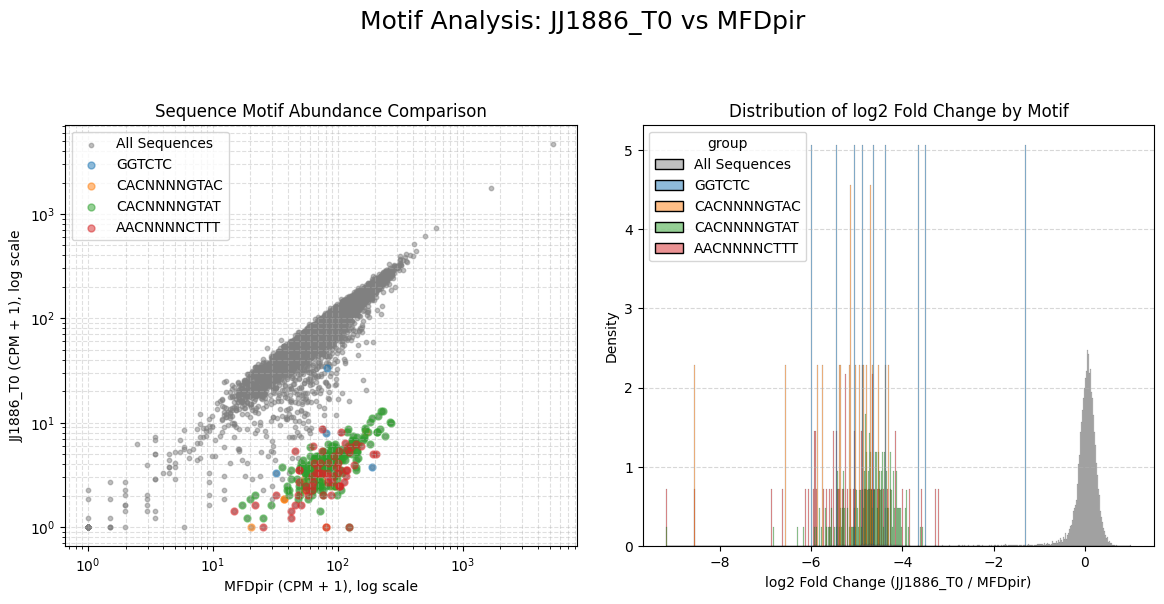

In [ ]:
fig, axes = plot_motif_analysis(counts, "JJ1886_T0", "MFDpir", flexible_motifs_df, left, right)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()